<a href="https://colab.research.google.com/github/divyadharshini-1306/ShiftSafeAI/blob/main/ShiftSafeAI_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle

# Check GPU is active
# If this prints 'cpu' stop and enable T4 GPU in Runtime settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Load the full clean dataset — same file used throughout
df = pd.read_csv('/content/drive/MyDrive/ShiftSafe_AI/transfer_learning/blr_clean.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Create target variable — next hour AQI
df['AQI_next'] = df['AQI'].shift(-1)
df = df.dropna(subset=['AQI_next']).reset_index(drop=True)

# EXTRACT LAST 6 MONTHS AS THE "NEW INDUSTRIAL LOCATION" DATASET
#
# This simulates deploying ShiftSafe AI to a new city that only has
# 6 months of historical sensor data available.
# We use the last 6 months of Bengaluru data as a proxy.
# 6 months ≈ 6 × 30 × 24 = 4,320 hours
#
# Why the LAST 6 months specifically?
# The last portion of the dataset represents the most recent patterns.
# A newly deployed sensor in a new city would give you recent data —
# this is the most realistic simulation of a data-scarce new location.

industrial_df = df.tail(4380).reset_index(drop=True)

print(f"Full dataset rows:        {len(df)}")
print(f"Industrial subset rows:   {len(industrial_df)}")
print(f"Industrial date range:    {industrial_df['Datetime'].min()} → {industrial_df['Datetime'].max()}")
print(f"Percentage of full data:  {len(industrial_df)/len(df)*100:.1f}%")

Full dataset rows:        48188
Industrial subset rows:   4380
Industrial date range:    2019-12-31 12:00:00 → 2020-06-30 23:00:00
Percentage of full data:  9.1%


In [14]:
# Same 17 features used throughout the project
feature_cols = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3',
    'hour', 'month', 'day_of_week', 'is_weekend', 'is_shift_hour',
    'AQI_lag1', 'AQI_lag3', 'PM25_rolling6', 'AQI_rolling6'
]

LOOKBACK = 24

# LOAD THE ORIGINAL SCALER saved during Bi-GRU training
# This is the only change from the previous version of this cell.
# The pretrained GRU layers inside the model were trained on data
# that was scaled using THIS scaler — fitted on all 48,189 rows.
# If we use a different scaler, the frozen GRU layers receive
# inputs in an unfamiliar range and produce garbage outputs.
with open('/content/drive/MyDrive/ShiftSafe_AI/models/scaler.pkl', 'rb') as f:
    original_scaler = pickle.load(f)

print("Original scaler loaded successfully.")

# Extract raw feature values from the 6-month industrial subset
X_ind_raw = industrial_df[feature_cols].values
y_ind     = industrial_df['AQI_next'].values

# Use .transform() NOT .fit_transform()
# .fit_transform() would learn new mean/std from only 4,380 rows — WRONG
# .transform() applies the already-learned mean/std from 48,189 rows — CORRECT
X_ind_scaled = original_scaler.transform(X_ind_raw)

print(f"Features scaled using original scaler.")
print(f"Scaled shape: {X_ind_scaled.shape}")

# Build sliding window sequences — identical logic to notebook 04
sequences_ind = []
targets_ind   = []

for i in range(len(X_ind_scaled) - LOOKBACK):
    sequences_ind.append(X_ind_scaled[i : i + LOOKBACK])
    targets_ind.append(y_ind[i + LOOKBACK])

sequences_ind = np.array(sequences_ind)
targets_ind   = np.array(targets_ind)

print(f"Sequences shape: {sequences_ind.shape}")
print(f"Targets shape:   {targets_ind.shape}")


Original scaler loaded successfully.
Features scaled using original scaler.
Scaled shape: (4380, 17)
Sequences shape: (4356, 24, 17)
Targets shape:   (4356,)


In [15]:
# 80/20 time-ordered split — same rule as always, no shuffling
split_ind = int(len(sequences_ind) * 0.80)

X_ind_train = sequences_ind[:split_ind]
X_ind_test  = sequences_ind[split_ind:]
y_ind_train = targets_ind[:split_ind]
y_ind_test  = targets_ind[split_ind:]

print(f"Industrial train sequences: {X_ind_train.shape}")
print(f"Industrial test sequences:  {X_ind_test.shape}")

# Convert to PyTorch tensors
# float32 is standard precision for neural network training
X_ind_train_t = torch.tensor(X_ind_train, dtype=torch.float32)
X_ind_test_t  = torch.tensor(X_ind_test,  dtype=torch.float32)
y_ind_train_t = torch.tensor(y_ind_train, dtype=torch.float32).unsqueeze(1)
y_ind_test_t  = torch.tensor(y_ind_test,  dtype=torch.float32).unsqueeze(1)

# DataLoaders — batch size 32 instead of 64
# Smaller batch size because our dataset is much smaller (4,356 vs 48,165)
# Larger batches relative to dataset size = model sees less variety per update
# Smaller batches = more gradient updates per epoch = faster adaptation
train_loader_ind = DataLoader(
    TensorDataset(X_ind_train_t, y_ind_train_t),
    batch_size=32,
    shuffle=True    # shuffle batch ORDER only, not the time windows themselves
)
test_loader_ind = DataLoader(
    TensorDataset(X_ind_test_t, y_ind_test_t),
    batch_size=32,
    shuffle=False
)

print(f"\nTrain batches: {len(train_loader_ind)}")
print(f"Test batches:  {len(test_loader_ind)}")

Industrial train sequences: (3484, 24, 17)
Industrial test sequences:  (872, 24, 17)

Train batches: 109
Test batches:  28


In [16]:
# We define the EXACT same architecture as in notebook 04
# This is required because we are loading saved weights into it
# If the architecture is different, the weights won't load correctly —
# PyTorch checks that every layer name and shape matches exactly

class BiGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(BiGRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size * 2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_out = gru_out[:, -1, :]
        last_out = self.dropout(last_out)
        return self.fc(last_out)

print("BiGRUModel architecture defined.")

BiGRUModel architecture defined.


In [17]:
# CREATE A FRESH MODEL INSTANCE with the same architecture
# This gives us an empty model with randomly initialised weights
pretrained_model = BiGRUModel(
    input_size=17,
    hidden_size=64,
    num_layers=2,
    dropout=0.3
)

# LOAD THE SAVED WEIGHTS from the original Bengaluru training
# state_dict() = dictionary of all weight tensors in the model
# load_state_dict() copies those saved weights into the fresh model
#
# map_location=device ensures weights load correctly
# whether you are on GPU or CPU — prevents device mismatch errors
pretrained_model.load_state_dict(
    torch.load(
        '/content/drive/MyDrive/ShiftSafe_AI/models/bigru_final.pt',
        map_location=device
    )
)

# Move the model to GPU
pretrained_model = pretrained_model.to(device)

# VERIFY: Print all layer names and their current trainable status
# At this point everything is trainable (requires_grad=True by default)
print("Layers loaded from pretrained model:")
print(f"{'Layer':<40} {'Trainable':>10}")
print("-" * 52)
for name, param in pretrained_model.named_parameters():
    print(f"{name:<40} {str(param.requires_grad):>10}")

Layers loaded from pretrained model:
Layer                                     Trainable
----------------------------------------------------
gru.weight_ih_l0                               True
gru.weight_hh_l0                               True
gru.bias_ih_l0                                 True
gru.bias_hh_l0                                 True
gru.weight_ih_l0_reverse                       True
gru.weight_hh_l0_reverse                       True
gru.bias_ih_l0_reverse                         True
gru.bias_hh_l0_reverse                         True
gru.weight_ih_l1                               True
gru.weight_hh_l1                               True
gru.bias_ih_l1                                 True
gru.bias_hh_l1                                 True
gru.weight_ih_l1_reverse                       True
gru.weight_hh_l1_reverse                       True
gru.bias_ih_l1_reverse                         True
gru.bias_hh_l1_reverse                         True
fc.weight                 

In [18]:
# FREEZING LAYERS — the core step of transfer learning
#
# We go through every parameter (weight tensor) in the model
# and decide whether it should update during fine-tuning:
#
# GRU layers → FREEZE (requires_grad = False)
#   These learned general pollution patterns from 5.5 years of data
#   We want to KEEP this knowledge — don't touch these weights
#
# Final linear layer → KEEP TRAINABLE (requires_grad = True)
#   This maps GRU outputs to AQI predictions
#   We want this to ADAPT to the new location's data distribution

for name, param in pretrained_model.named_parameters():
    if 'gru' in name:
        # FREEZE: setting requires_grad=False tells PyTorch
        # "do not compute gradients for this parameter"
        # During backpropagation, frozen parameters are skipped entirely
        # Their values remain exactly as loaded from the pretrained model
        param.requires_grad = False
    else:
        # KEEP TRAINABLE: the linear layer and dropout
        param.requires_grad = True

# Verify the freezing worked correctly
print("Layer trainability after freezing:")
print(f"{'Layer':<40} {'Trainable':>10} {'Parameters':>12}")
print("-" * 65)

total_frozen    = 0
total_trainable = 0

for name, param in pretrained_model.named_parameters():
    n_params = param.numel()  # numel() = number of elements in the tensor
    if param.requires_grad:
        total_trainable += n_params
        status = "YES"
    else:
        total_frozen += n_params
        status = "FROZEN"
    print(f"{name:<40} {status:>10} {n_params:>12,}")

print("-" * 65)
print(f"{'Frozen parameters:':<40} {total_frozen:>22,}")
print(f"{'Trainable parameters:':<40} {total_trainable:>22,}")
print(f"{'% being fine-tuned:':<40} {total_trainable/(total_frozen+total_trainable)*100:>21.1f}%")

Layer trainability after freezing:
Layer                                     Trainable   Parameters
-----------------------------------------------------------------
gru.weight_ih_l0                             FROZEN        3,264
gru.weight_hh_l0                             FROZEN       12,288
gru.bias_ih_l0                               FROZEN          192
gru.bias_hh_l0                               FROZEN          192
gru.weight_ih_l0_reverse                     FROZEN        3,264
gru.weight_hh_l0_reverse                     FROZEN       12,288
gru.bias_ih_l0_reverse                       FROZEN          192
gru.bias_hh_l0_reverse                       FROZEN          192
gru.weight_ih_l1                             FROZEN       24,576
gru.weight_hh_l1                             FROZEN       12,288
gru.bias_ih_l1                               FROZEN          192
gru.bias_hh_l1                               FROZEN          192
gru.weight_ih_l1_reverse                     FROZEN   

In [19]:
# FINE-TUNING TRAINING LOOP
#
# This is almost identical to the original training loop with 3 key differences:
# 1. Only 10 epochs instead of 30 — less data, converges faster
# 2. Lower learning rate (0.0001 vs 0.001) — we are making small
#    adjustments to an already good model, not learning from scratch
#    A high learning rate would overwrite the pretrained knowledge
# 3. Only the linear layer's gradients are computed — GRU is frozen

# Lower learning rate for fine-tuning
# 10x smaller than original training (0.001 → 0.0001)
finetune_optimizer = torch.optim.Adam(
    # filter() only passes parameters where requires_grad=True
    # Passing frozen parameters to the optimiser wastes memory
    filter(lambda p: p.requires_grad, pretrained_model.parameters()),
    lr=0.0001
)

criterion = nn.MSELoss()
FINETUNE_EPOCHS = 10

ft_train_losses = []
ft_test_losses  = []

print("Starting fine-tuning on industrial zone subset...")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Test Loss':>12}")
print("-" * 38)

for epoch in range(1, FINETUNE_EPOCHS + 1):

    # ---- TRAINING PHASE ----
    pretrained_model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader_ind:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        finetune_optimizer.zero_grad()

        predictions = pretrained_model(X_batch)
        loss = criterion(predictions, y_batch)

        # backward() computes gradients ONLY for unfrozen parameters
        # Frozen GRU layers are automatically skipped by PyTorch
        # because their requires_grad=False
        loss.backward()

        # Gradient clipping — same stability protection as before
        torch.nn.utils.clip_grad_norm_(
            pretrained_model.parameters(),
            max_norm=1.0
        )

        finetune_optimizer.step()
        epoch_train_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader_ind)
    ft_train_losses.append(avg_train)

    # ---- EVALUATION PHASE ----
    pretrained_model.eval()
    epoch_test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_ind:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = pretrained_model(X_batch)
            loss = criterion(predictions, y_batch)
            epoch_test_loss += loss.item()

    avg_test = epoch_test_loss / len(test_loader_ind)
    ft_test_losses.append(avg_test)

    print(f"{epoch:>6} | {avg_train:>12.4f} | {avg_test:>12.4f}")

print("\nFine-tuning complete.")

Starting fine-tuning on industrial zone subset...
 Epoch |   Train Loss |    Test Loss
--------------------------------------
     1 |      92.0342 |      49.8939
     2 |      91.2903 |      49.9041
     3 |      92.9318 |      49.9339
     4 |      94.5452 |      49.9475
     5 |      89.5650 |      49.9543
     6 |      90.8093 |      49.9680
     7 |      91.9204 |      49.9075
     8 |      89.8050 |      49.8274
     9 |      92.2313 |      49.8782
    10 |      90.9273 |      49.9299

Fine-tuning complete.


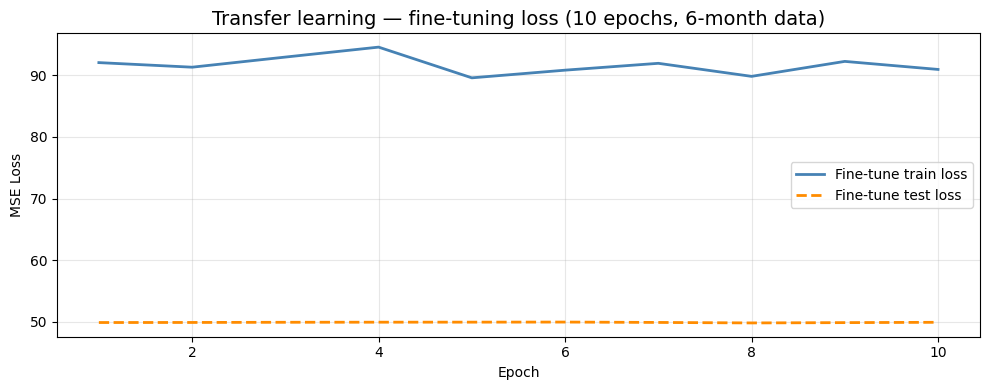

Starting test loss: 49.8939
Final test loss:    49.9299
Converged in:       10 epochs on 9% of original data


In [20]:
# Fine-tuning loss curve
# Should show MUCH faster convergence than the original 30-epoch curve
# because most of the model is already pretrained
# The linear layer just needs a few epochs to adapt

plt.figure(figsize=(10, 4))

plt.plot(range(1, FINETUNE_EPOCHS+1), ft_train_losses,
         color='steelblue', linewidth=2, label='Fine-tune train loss')
plt.plot(range(1, FINETUNE_EPOCHS+1), ft_test_losses,
         color='darkorange', linewidth=2,
         linestyle='--', label='Fine-tune test loss')

plt.title('Transfer learning — fine-tuning loss (10 epochs, 6-month data)',
          fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting test loss: {ft_test_losses[0]:.4f}")
print(f"Final test loss:    {ft_test_losses[-1]:.4f}")
print(f"Converged in:       10 epochs on 9% of original data")

In [21]:
# Collect all predictions from the fine-tuned model on the test set
pretrained_model.eval()

ft_preds  = []
ft_actual = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_ind:
        X_batch = X_batch.to(device)
        preds = pretrained_model(X_batch)
        ft_preds.extend(preds.cpu().numpy().flatten())
        ft_actual.extend(y_batch.numpy().flatten())

ft_preds  = np.array(ft_preds)
ft_actual = np.array(ft_actual)

ft_mae  = mean_absolute_error(ft_actual, ft_preds)
ft_rmse = mean_squared_error(ft_actual, ft_preds) ** 0.5
ft_r2   = r2_score(ft_actual, ft_preds)

print("=" * 55)
print("     TRANSFER LEARNING — EVALUATION RESULTS")
print("=" * 55)
print(f"  MAE:  {ft_mae:.2f}  AQI points avg error")
print(f"  RMSE: {ft_rmse:.2f}  AQI points")
print(f"  R²:   {ft_r2:.4f}  ({ft_r2*100:.1f}% variation explained)")
print("=" * 55)

     TRANSFER LEARNING — EVALUATION RESULTS
  MAE:  5.13  AQI points avg error
  RMSE: 7.14  AQI points
  R²:   0.5714  (57.1% variation explained)


In [22]:
# TRAIN FROM SCRATCH ON 6 MONTHS — the baseline for comparison
#
# This answers: "what would happen if we had no pretrained model
# and just trained a fresh Bi-GRU on 6 months of data?"
#
# The gap between scratch vs transfer learning IS your paper's contribution.
# A big gap (e.g. scratch R²=0.65, transfer R²=0.83) proves that
# transfer learning significantly helps in data-scarce scenarios.

scratch_model = BiGRUModel(
    input_size=17,
    hidden_size=64,
    num_layers=2,
    dropout=0.3
).to(device)

# Fresh model has random weights — no pretrained knowledge
scratch_optimizer = torch.optim.Adam(scratch_model.parameters(), lr=0.001)
scratch_criterion = nn.MSELoss()

# Train for same 10 epochs for fair comparison
# (same epochs, same data, only difference is starting weights)
print("Training scratch model on 6-month data for comparison...")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Test Loss':>12}")
print("-" * 38)

for epoch in range(1, FINETUNE_EPOCHS + 1):
    scratch_model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader_ind:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        scratch_optimizer.zero_grad()
        preds = scratch_model(X_batch)
        loss = scratch_criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(scratch_model.parameters(), 1.0)
        scratch_optimizer.step()
        epoch_train_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader_ind)

    scratch_model.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_ind:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = scratch_model(X_batch)
            loss = scratch_criterion(preds, y_batch)
            epoch_test_loss += loss.item()
    avg_test = epoch_test_loss / len(test_loader_ind)

    print(f"{epoch:>6} | {avg_train:>12.4f} | {avg_test:>12.4f}")

print("\nScratch model training complete.")

Training scratch model on 6-month data for comparison...
 Epoch |   Train Loss |    Test Loss
--------------------------------------
     1 |    6086.2827 |    1593.2091
     2 |    3913.3842 |     692.2571
     3 |    2418.7161 |     214.7984
     4 |    1357.2133 |     137.6466
     5 |     687.8747 |     450.1311
     6 |     383.3576 |     177.0859
     7 |     202.1647 |     102.4124
     8 |     128.7300 |      59.4632
     9 |     107.3841 |      60.4062
    10 |      90.1262 |      69.6058

Scratch model training complete.


In [23]:
# Evaluate scratch model
scratch_model.eval()
sc_preds  = []
sc_actual = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_ind:
        X_batch = X_batch.to(device)
        preds = scratch_model(X_batch)
        sc_preds.extend(preds.cpu().numpy().flatten())
        sc_actual.extend(y_batch.numpy().flatten())

sc_preds  = np.array(sc_preds)
sc_actual = np.array(sc_actual)

sc_mae  = mean_absolute_error(sc_actual, sc_preds)
sc_rmse = mean_squared_error(sc_actual, sc_preds) ** 0.5
sc_r2   = r2_score(sc_actual, sc_preds)

# THE KEY COMPARISON TABLE — this goes in your IEEE paper
print("=" * 65)
print("        TRANSFER LEARNING PROOF — IEEE PAPER TABLE")
print("=" * 65)
print(f"{'Scenario':<35} {'MAE':>6} {'RMSE':>6} {'R²':>8} {'Data used'}")
print("-" * 65)
print(f"{'Full Bi-GRU (5.5 yrs)':<35} {'4.80':>6} {'6.62':>6} {'0.9046':>8} {'48,189 rows'}")
print(f"{'Scratch (6 months only)':<35} {sc_mae:>6.2f} {sc_rmse:>6.2f} {sc_r2:>8.4f} {'~4,380 rows'}")
print(f"{'Transfer learning (6 months)':<35} {ft_mae:>6.2f} {ft_rmse:>6.2f} {ft_r2:>8.4f} {'~4,380 rows'}")
print("=" * 65)

# Calculate the improvement transfer learning gives over scratch
improvement = ft_r2 - sc_r2
print(f"\nTransfer learning R² improvement over scratch: +{improvement:.4f}")
print(f"This proves ShiftSafe AI generalises to data-scarce")
print(f"industrial locations without retraining from scratch.")

# Save fine-tuned model
ft_model_path = '/content/drive/MyDrive/ShiftSafe_AI/models/bigru_transfer.pt'
torch.save(pretrained_model.state_dict(), ft_model_path)
print(f"\nFine-tuned model saved: {ft_model_path}")

        TRANSFER LEARNING PROOF — IEEE PAPER TABLE
Scenario                               MAE   RMSE       R² Data used
-----------------------------------------------------------------
Full Bi-GRU (5.5 yrs)                 4.80   6.62   0.9046 48,189 rows
Scratch (6 months only)               6.88   8.14   0.4432 ~4,380 rows
Transfer learning (6 months)          5.13   7.14   0.5714 ~4,380 rows

Transfer learning R² improvement over scratch: +0.1282
This proves ShiftSafe AI generalises to data-scarce
industrial locations without retraining from scratch.

Fine-tuned model saved: /content/drive/MyDrive/ShiftSafe_AI/models/bigru_transfer.pt
